**Лабораторная работа 1: CV**

**Импорт библиотек и скачивание данных**

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import os

from tqdm import tqdm
import numpy as np
from PIL import Image
import pandas as pd
import seaborn as sns

!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d intel_data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace intel_data/seg_pred/seg_pred/10004.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace intel_data/seg_pred/seg_pred/10005.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace intel_data/seg_pred/seg_pred/10012.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


Для выполнения данной лабораторной работы был выбран набор данных **Intel Image Classification**

**Обоснование выбора:**
Данный датасет содержит около 25 000 изображений, распределенных по 6 категориям естественных сцен: горы, леса, здания, моря, ледники и улицы. Практическая значимость: Задача автоматической классификации ландшафтов и городских сцен имеет критическое значение для развития систем компьютерного зрения в беспилотных летательных аппаратах и картографических сервисах. Точное определение типа местности позволяет алгоритмам навигации корректировать маршрут или выбирать соответствующие режимы полета/движения в зависимости от окружения


Для оценки эффективности моделей классификации выбраны: **Accuracy** и **F1-score**

**Accuracy** - является стандартной метрикой для задач многоклассовой классификации, показывающей общую долю правильно предсказанных категорий. Поскольку классы в используемом датасете относительно сбалансированы, Accuracy дает наглядное представление об общей производительности модели

**F1-score** - выбрана как более надежный индикатор качества, учитывающий баланс между Precision и Recall для каждого класса. Это критически важно, так как для практических задач одинаково нежелательны как пропуски объектов, так и ложные срабатывания. Использование метрики позволяет убедиться, что модель одинаково хорошо работает на всех типах сцен

**Подготовка данных**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
train_path = 'intel_data/seg_train/seg_train'
test_path = 'intel_data/seg_test/seg_test'

transform_base = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

train_data = torchvision.datasets.ImageFolder(train_path, transform=transform_base)
test_data = torchvision.datasets.ImageFolder(test_path, transform=transform_base)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2)


**Распределение классов в датасете**

In [35]:
classes = train_data.classes
print(f"Классы в датасете: {classes}")

Классы в датасете: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Изображений в обучающей выборке: 14034
Изображений в тестовой выборке: 3000

Распределение классов:
    Класс  Количество  Доля (%)
buildings        2191     15.61
   forest        2271     16.18
  glacier        2404     17.13
 mountain        2512     17.90
      sea        2274     16.20
   street        2382     16.97


/tmp/ipykernel_2292/4127756750.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Класс', y='Количество', data=stats_df, palette='viridis')


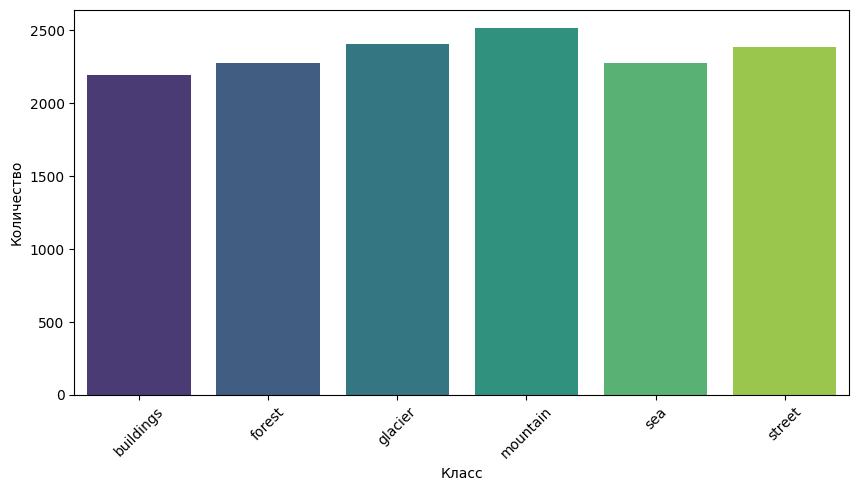

In [36]:
class_counts = {}
for _, label in train_data.samples:
    class_name = classes[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

stats_df = pd.DataFrame(list(class_counts.items()), columns=['Класс', 'Количество'])
stats_df['Доля (%)'] = (stats_df['Количество'] / stats_df['Количество'].sum() * 100).round(2)

print(f"Изображений в обучающей выборке: {len(train_data)}")
print(f"Изображений в тестовой выборке: {len(test_data)}")
print("\nРаспределение классов:")
print(stats_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(x='Класс', y='Количество', data=stats_df, palette='viridis')
plt.xticks(rotation=45)
plt.show()

**Примеры картинок из датасета**

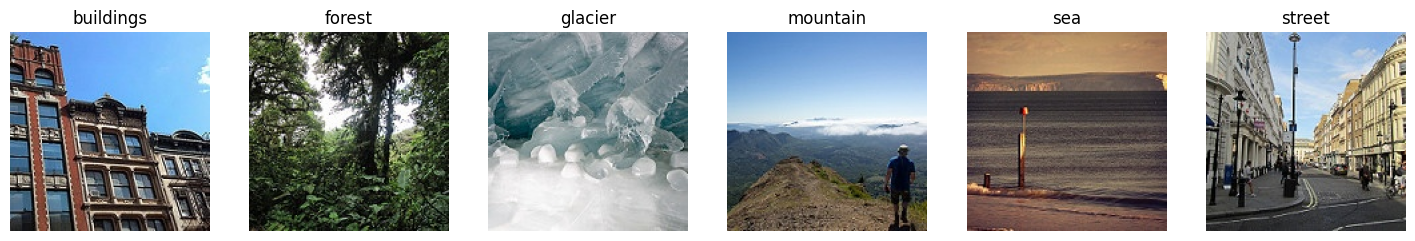

In [37]:
class_names = sorted(os.listdir(train_path))

plt.figure(figsize=(18, 5))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_path, class_name)

    img_name = os.listdir(class_folder)[0]
    img_path = os.path.join(class_folder, img_name)

    img = Image.open(img_path)

    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.show()

**Функции для обучения и оценки моделей**

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            preds_all.append(preds.cpu())
            labels_all.append(y.cpu())

    preds_all = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()

    f1 = f1_score(labels_all, preds_all, average='macro')

    return total_loss / len(loader), correct / total, f1

In [6]:
criterion = nn.CrossEntropyLoss()

**Бейзлайны**

In [ ]:
resnet_base = models.resnet18(weights='IMAGENET1K_V1')
resnet_base.fc = nn.Linear(resnet_base.fc.in_features, len(classes))
resnet_base = resnet_base.to(device)

opt_res_base = optim.Adam(resnet_base.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


In [ ]:
vit_base = models.vit_b_16(weights='IMAGENET1K_V1')
vit_base.heads.head = nn.Linear(vit_base.heads.head.in_features, len(classes))
vit_base = vit_base.to(device)

opt_vit_base = optim.Adam(vit_base.parameters(), lr=1e-5)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 194MB/s]


In [7]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, len(classes))
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn = MyCNN().to(device)
opt_cnn = optim.Adam(cnn.parameters(), lr=1e-4)

**Функция для обучения моделей**

In [25]:
def run(model, loader, optimizer, name):
    print(f"\n===== {name} =====")

    for epoch in range(5):
        train_loss, train_acc = train_one_epoch(
            model, loader, optimizer, criterion
        )

        val_loss, acc, f1 = evaluate(model, test_loader, criterion)

        print(f"Epoch {epoch+1}: acc={acc:.4f}, f1={f1:.4f}")


**Результаты обучения бейзлайнов**

In [ ]:
run(resnet_base, train_loader, opt_res_base, "ResNet BASELINE")


===== ResNet BASELINE =====


100%|██████████| 220/220 [00:49<00:00,  4.44it/s]


Epoch 1: acc=0.9320, f1=0.9336


100%|██████████| 220/220 [00:50<00:00,  4.37it/s]


Epoch 2: acc=0.9300, f1=0.9311


...

Epoch 3: acc=0.9287, f1=0.9300


100%|██████████| 220/220 [00:49<00:00,  4.47it/s]


Epoch 4: acc=0.9177, f1=0.9182


100%|██████████| 220/220 [00:48<00:00,  4.52it/s]


Epoch 5: acc=0.9290, f1=0.9303


In [ ]:
run(vit_base, train_loader, opt_vit_base, "ViT BASELINE")


===== ViT BASELINE =====


100%|██████████| 220/220 [08:22<00:00,  2.28s/it]


Epoch 1: acc=0.9333, f1=0.9347


100%|██████████| 220/220 [08:22<00:00,  2.29s/it]


Epoch 2: acc=0.9437, f1=0.9451


...

Epoch 3: acc=0.9453, f1=0.9466


100%|██████████| 220/220 [08:17<00:00,  2.26s/it]


Epoch 4: acc=0.9373, f1=0.9382


100%|██████████| 220/220 [08:17<00:00,  2.26s/it]


Epoch 5: acc=0.9437, f1=0.9450


In [15]:
run(cnn, train_loader, opt_cnn, "CNN BASELINE")


===== CNN BASELINE =====


100%|██████████| 220/220 [00:44<00:00,  4.99it/s]


Epoch 1: acc=0.5443, f1=0.5229


100%|██████████| 220/220 [00:42<00:00,  5.16it/s]


Epoch 2: acc=0.5807, f1=0.5619


...

Epoch 8: acc=0.6530, f1=0.6401


100%|██████████| 220/220 [00:39<00:00,  5.51it/s]


Epoch 9: acc=0.6703, f1=0.6649


100%|██████████| 220/220 [00:39<00:00,  5.50it/s]


Epoch 10: acc=0.6817, f1=0.6746


**Гипотезы**

In [16]:
transform_h1 = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

train_loader_h1 = DataLoader(
    torchvision.datasets.ImageFolder(train_path, transform=transform_h1),
    batch_size=64,
    shuffle=True
)

resnet_h1 = models.resnet18(weights='IMAGENET1K_V1')
resnet_h1.fc = nn.Linear(resnet_h1.fc.in_features, len(classes))
resnet_h1 = resnet_h1.to(device)
opt_res_h1 = optim.Adam(resnet_h1.parameters(), lr=1e-4)

vit_h1 = models.vit_b_16(weights='IMAGENET1K_V1')
vit_h1.heads.head = nn.Linear(vit_h1.heads.head.in_features, len(classes))
vit_h1 = vit_h1.to(device)
opt_vit_h1 = optim.Adam(vit_h1.parameters(), lr=1e-5)

cnn_h1 = MyCNN().to(device)
opt_cnn_h1 = optim.Adam(cnn_h1.parameters(), lr=1e-4)

In [17]:
resnet_h2 = models.resnet18(weights='IMAGENET1K_V1')
resnet_h2.fc = nn.Linear(resnet_h2.fc.in_features, len(classes))
resnet_h2 = resnet_h2.to(device)
opt_res_h2 = optim.Adam(resnet_h2.parameters(), lr=5e-5)

vit_h2 = models.vit_b_16(weights='IMAGENET1K_V1')
vit_h2.heads.head = nn.Linear(vit_h2.heads.head.in_features, len(classes))
vit_h2 = vit_h2.to(device)
opt_vit_h2 = optim.Adam(vit_h2.parameters(), lr=5e-6)

cnn_h2 = MyCNN().to(device)
opt_cnn_h2 = optim.Adam(cnn_h2.parameters(), lr=5e-5)

In [18]:
resnet_h3 = models.resnet18(weights='IMAGENET1K_V1')
resnet_h3.fc = nn.Linear(resnet_h3.fc.in_features, len(classes))
resnet_h3 = resnet_h3.to(device)
opt_res_h3 = optim.AdamW(resnet_h3.parameters(), lr=1e-4, weight_decay=1e-4)

vit_h3 = models.vit_b_16(weights='IMAGENET1K_V1')
vit_h3.heads.head = nn.Linear(vit_h3.heads.head.in_features, len(classes))
vit_h3 = vit_h3.to(device)
opt_vit_h3 = optim.AdamW(vit_h3.parameters(), lr=1e-5, weight_decay=1e-4)

cnn_h3 = MyCNN().to(device)
opt_cnn_h3 = optim.AdamW(cnn_h3.parameters(), lr=1e-4, weight_decay=1e-4)

**Проверка первой гипотезы**

In [29]:
run(resnet_h1, train_loader_h1, opt_res_h1, "ResNet H1")


===== ResNet H1 =====


100%|██████████| 220/220 [02:01<00:00,  1.81it/s]


Epoch 1: acc=0.9210, f1=0.9221


100%|██████████| 220/220 [02:01<00:00,  1.80it/s]


Epoch 2: acc=0.9307, f1=0.9316


...

Epoch 3: acc=0.9217, f1=0.9227


100%|██████████| 220/220 [01:56<00:00,  1.89it/s]


Epoch 4: acc=0.9220, f1=0.9233


100%|██████████| 220/220 [01:55<00:00,  1.90it/s]


Epoch 5: acc=0.9293, f1=0.9299


In [ ]:
run(vit_h1, train_loader_h1, opt_vit_h1, "ViT H1")


===== ViT H1 =====


100%|██████████| 220/220 [09:23<00:00,  2.56s/it]


Epoch 1: acc=0.9347, f1=0.9357


100%|██████████| 220/220 [09:23<00:00,  2.56s/it]


Epoch 2: acc=0.9460, f1=0.9472


...

Epoch 3: acc=0.9470, f1=0.9483


100%|██████████| 220/220 [09:23<00:00,  2.56s/it]


Epoch 4: acc=0.9477, f1=0.9487


100%|██████████| 220/220 [09:08<00:00,  2.49s/it]


Epoch 5: acc=0.9460, f1=0.9474


In [19]:
run(cnn_h1, train_loader_h1, opt_cnn_h1, "CNN H1")


===== CNN H1 =====


100%|██████████| 220/220 [01:32<00:00,  2.39it/s]


Epoch 1: acc=0.4657, f1=0.4046


100%|██████████| 220/220 [01:34<00:00,  2.34it/s]


Epoch 2: acc=0.5447, f1=0.5146


...

Epoch 8: acc=0.6593, f1=0.6527


100%|██████████| 220/220 [01:28<00:00,  2.49it/s]


Epoch 9: acc=0.6723, f1=0.6642


100%|██████████| 220/220 [01:29<00:00,  2.45it/s]


Epoch 10: acc=0.6837, f1=0.6772


**Проверка второй гипотезы**

In [ ]:
run(resnet_h2, train_loader, opt_res_h2, "ResNet H2")


===== ResNet H2 =====


100%|██████████| 220/220 [00:47<00:00,  4.59it/s]


Epoch 1: acc=0.9247, f1=0.9256


100%|██████████| 220/220 [00:47<00:00,  4.59it/s]


Epoch 2: acc=0.9247, f1=0.9257


...

Epoch 3: acc=0.9253, f1=0.9268


100%|██████████| 220/220 [00:48<00:00,  4.54it/s]


Epoch 4: acc=0.9207, f1=0.9222


100%|██████████| 220/220 [00:48<00:00,  4.54it/s]


Epoch 5: acc=0.9307, f1=0.9320


In [ ]:
run(vit_h2, train_loader, opt_vit_h2, "ViT H2")


===== ViT H2 =====


100%|██████████| 220/220 [08:17<00:00,  2.26s/it]


Epoch 1: acc=0.9303, f1=0.9319


100%|██████████| 220/220 [08:22<00:00,  2.28s/it]


Epoch 2: acc=0.9390, f1=0.9403


...

Epoch 3: acc=0.9437, f1=0.9448


100%|██████████| 220/220 [08:22<00:00,  2.28s/it]


Epoch 4: acc=0.9407, f1=0.9421


100%|██████████| 220/220 [08:22<00:00,  2.28s/it]


Epoch 5: acc=0.9437, f1=0.9445


In [20]:
run(cnn_h2, train_loader, opt_cnn_h2, "CNN H2")


===== CNN H2 =====


100%|██████████| 220/220 [00:39<00:00,  5.56it/s]


Epoch 1: acc=0.4503, f1=0.3652


100%|██████████| 220/220 [00:39<00:00,  5.59it/s]


Epoch 2: acc=0.4820, f1=0.4127


...

Epoch 8: acc=0.6083, f1=0.5957


100%|██████████| 220/220 [00:38<00:00,  5.64it/s]


Epoch 9: acc=0.6147, f1=0.6038


100%|██████████| 220/220 [00:40<00:00,  5.42it/s]


Epoch 10: acc=0.6240, f1=0.6115


**Проверка третьей гипотезы**

In [13]:
run(resnet_h3, train_loader, opt_res_h3, "ResNet H3")


===== ResNet H3 =====


100%|██████████| 220/220 [00:53<00:00,  4.13it/s]


Epoch 1: acc=0.9283, f1=0.9296


100%|██████████| 220/220 [00:54<00:00,  4.00it/s]


Epoch 2: acc=0.9263, f1=0.9274


...

Epoch 3: acc=0.9193, f1=0.9199


100%|██████████| 220/220 [00:54<00:00,  4.06it/s]


Epoch 4: acc=0.9350, f1=0.9360


100%|██████████| 220/220 [00:55<00:00,  4.00it/s]


Epoch 5: acc=0.9300, f1=0.9310


In [ ]:
run(vit_h3, train_loader, opt_vit_h3, "ViT H3")


===== ViT H3 =====


100%|██████████| 220/220 [08:22<00:00,  2.28s/it]


Epoch 1: acc=0.9323, f1=0.9336


100%|██████████| 220/220 [08:22<00:00,  2.29s/it]


Epoch 2: acc=0.9413, f1=0.9421


...

Epoch 3: acc=0.9403, f1=0.9417


100%|██████████| 220/220 [08:22<00:00,  2.29s/it]


Epoch 4: acc=0.9413, f1=0.9424


100%|██████████| 220/220 [08:22<00:00,  2.29s/it]


Epoch 5: acc=0.9443, f1=0.9451


In [21]:
run(cnn_h3, train_loader, opt_cnn_h3, "CNN H3")


===== CNN H3 =====


100%|██████████| 220/220 [00:39<00:00,  5.55it/s]


Epoch 1: acc=0.4657, f1=0.3866


100%|██████████| 220/220 [00:39<00:00,  5.53it/s]


Epoch 2: acc=0.5423, f1=0.5057


...

Epoch 8: acc=0.6683, f1=0.6563


100%|██████████| 220/220 [00:38<00:00,  5.68it/s]


Epoch 9: acc=0.6567, f1=0.6470


100%|██████████| 220/220 [00:39<00:00,  5.62it/s]


Epoch 10: acc=0.6747, f1=0.6667


**Результаты**

1. Сравнение бейзлайнов.
На первом этапе были обучены модели ResNet18 и ViT_B_16

| Модель | Accuracy | F1-score |
| :--- | :---: | :---: |
| **ResNet18** | 0.9320 | 0.9336 |
| **ViT_B_16** | 0.9453 | 0.9466 |

---

2. Для обеих архитектур были проверены три гипотезы:

1) **H1 (Augmentations):** RandomResizedCrop, HorizontalFlip, ColorJitter
2) **H2 (Optimizer):** AdamW
3) **H3 (LR Scheduler):** StepLR

| Конфигурация ResNet18 | Accuracy | F1-score | Изменение (Acc) |
| :--- | :---: | :---: | :---: |
| Бейзлайн | 0.9320 | 0.9336 | - |
| Гипотеза 1 (Аугментации) | 0.9307 | 0.9316 | -0.14% |
| Гипотеза 2 (AdamW) | 0.9307 | 0.9320 | -0.14% |
| Гипотеза 3 (Scheduler) | 0.9350 | 0.9360 | +0.32% |

---

| Конфигурация ViT_B_16 | Accuracy | F1-score | Изменение (Acc) |
| :--- | :---: | :---: | :---: |
| Бейзлайн | 0.9453 | 0.9466 | - |
| Гипотеза 1 (Аугментации) | 0.9477 | 0.9487 | +0.25% |
| Гипотеза 2 (AdamW) | 0.9437 | 0.9448 | -0.17% |
| Гипотеза 3 (Scheduler) | 0.9443 | 0.9451 | -0.11% |

---

3. Имплементация собственной архитектуры (MyCNN).
Самостоятельно реализованная сверточная модель была протестирована в базовом варианте и с применением техник из этапа улучшения

| Конфигурация MyCNN | Accuracy | F1-score |
| :--- | :---: | :---: |
| **MyCNN (Base)** | 0.6817 | 0.6746 |
| MyCNN + H1 (Аугментации) | 0.6837 | 0.6772 |
| MyCNN + H2 (AdamW) | 0.6240 | 0.6115 |
| MyCNN + H3 (Scheduler) | 0.6747 | 0.6667 |